Nearest element index: 32983


C:\Users\sahad2\AppData\Local\Temp\ipykernel_29916\4033206785.py:43: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = ax.pcolormesh(theta, r, energy_spectrum.T, cmap="gray", shading='auto')


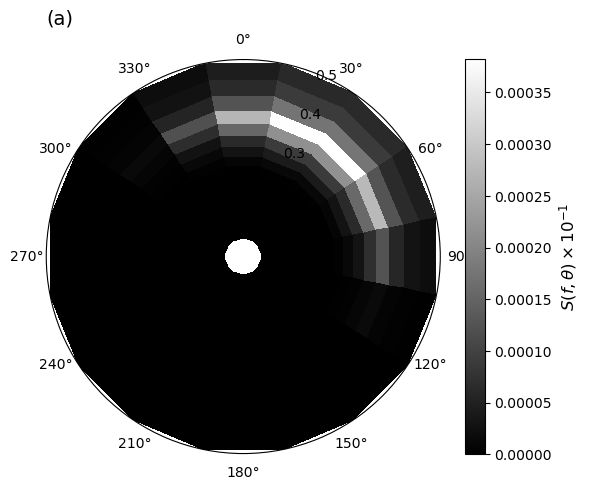

In [18]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path (update this to the correct file)
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(wave_energy_file)

# Target coordinates (update to your specific location)
target_coord = (736253, 3177009)

# Extract element center coordinates
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest element index
distances = np.linalg.norm(elem_coords - np.array(target_coord), axis=1)
nearest_idx = np.argmin(distances)

print(f"Nearest element index: {nearest_idx}")

# Read wave energy density data
data = ds.read(items=["Energy density"])

# Extract time-series for the nearest element
wave_energy_spectrum = data[0].values[:, nearest_idx, :, :]  # Shape: (Time, Directions, Frequencies)

# Time, directions, and frequencies
time = np.array(ds.time)
directions = np.deg2rad(np.array(ds.directions))  # Convert to radians for polar plot
frequencies = np.array(ds.frequencies)

# Select a time step (e.g., first timestep)
timestep = 0  
energy_spectrum = wave_energy_spectrum[timestep, :, :]  # Shape: (Directions, Frequencies)

# Create a polar plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

# Convert 2D data into a polar plot format
theta, r = np.meshgrid(directions, frequencies)  # θ = directions, r = frequencies
c = ax.pcolormesh(theta, r, energy_spectrum.T, cmap="gray", shading='auto')

# Add color bar
cb = plt.colorbar(c, ax=ax, orientation="vertical", shrink=0.7)
cb.set_label(r"$S(f,\theta) \times 10^{-1}$", fontsize=12, style="italic")

# Labels and formatting
ax.set_theta_zero_location("N")  # North at top
ax.set_theta_direction(-1)  # Clockwise angles
ax.set_xticks(np.radians([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]))  # Direction labels
ax.set_yticks(np.linspace(frequencies.min(), frequencies.max(), 5))  # Frequency labels
ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(frequencies.min(), frequencies.max(), 5)], fontsize=10)
ax.set_title("(a)", loc="left", fontsize=14)  # Subfigure label

# Adjust aspect ratio and layout
plt.tight_layout()
plt.show()


Nearest element index: 32983


C:\Users\sahad2\AppData\Local\Temp\ipykernel_29916\228403532.py:46: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = ax.pcolormesh(theta, r, masked_energy_spectrum.T, cmap="gray", shading='auto')


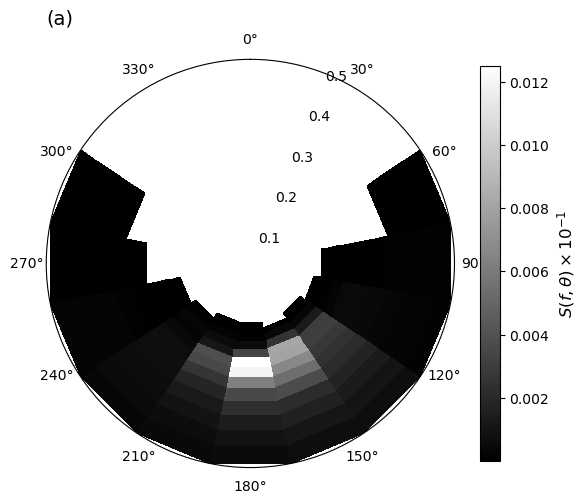

In [24]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# File path
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(wave_energy_file)

# Target coordinates (update to your specific location)
target_coord = (736253, 3177009)

# Extract element center coordinates
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest element index
distances = np.linalg.norm(elem_coords - np.array(target_coord), axis=1)
nearest_idx = np.argmin(distances)

print(f"Nearest element index: {nearest_idx}")

# Read only the nearest element
data = ds.read(items=["Energy density"], elements=[nearest_idx])

# Extract data for the nearest element
wave_energy_spectrum = data[0].values[:, :, :]  # Shape: (Time, Directions, Frequencies)

# Time, directions, and frequencies
time = np.array(ds.time)
directions = np.deg2rad(np.array(ds.directions))  # Convert to radians for polar plot
frequencies = np.array(ds.frequencies)

# Select a time step (e.g., first timestep)
timestep = 114  
energy_spectrum = wave_energy_spectrum[timestep, :, :]  # Shape: (Directions, Frequencies)

# Mask near-zero values (ignores values < 1e-6)
masked_energy_spectrum = np.ma.masked_where(energy_spectrum < 1e-6, energy_spectrum)

# Create a polar plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

# Convert 2D data into a polar plot format
theta, r = np.meshgrid(directions, frequencies)  # θ = directions, r = frequencies
c = ax.pcolormesh(theta, r, masked_energy_spectrum.T, cmap="gray", shading='auto')

# Add color bar
cb = plt.colorbar(c, ax=ax, orientation="vertical", shrink=0.7)
cb.set_label(r"$S(f,\theta) \times 10^{-1}$", fontsize=12, style="italic")

# Labels and formatting
ax.set_theta_zero_location("N")  # North at top
ax.set_theta_direction(-1)  # Clockwise angles
ax.set_xticks(np.radians([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]))  # Direction labels
ax.set_yticks(np.linspace(frequencies.min(), frequencies.max(), 5))  # Frequency labels
ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(frequencies.min(), frequencies.max(), 5)], fontsize=10)
ax.set_title("(a)", loc="left", fontsize=14)  # Subfigure label

# Adjust aspect ratio and layout
plt.tight_layout()
plt.show()


Nearest element index: 32983
T shape: (25, 229), F shape: (25, 229), Energy spectrum shape: (25, 229)


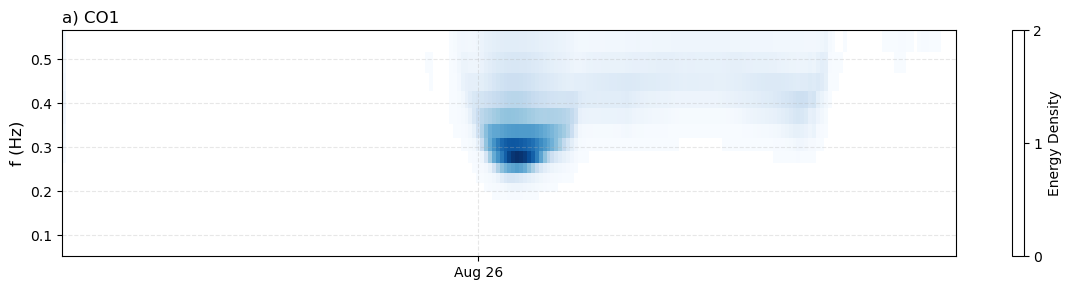

In [27]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(wave_energy_file)

# Target coordinates (update to your specific location)
target_coord = (736253, 3177009)

# Extract element center coordinates
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest element index
distances = np.linalg.norm(elem_coords - np.array(target_coord), axis=1)
nearest_idx = np.argmin(distances)

print(f"Nearest element index: {nearest_idx}")

# Read wave energy density data for the nearest element
data = ds.read(items=["Energy density"], elements=[nearest_idx])

# Extract data for the nearest element
wave_energy_spectrum = data[0].values[:, :, :]  # Shape: (Time, Directions, Frequencies)

# Time, directions, and frequencies
time = np.array(ds.time)  # Shape: (229,)
frequencies = np.array(ds.frequencies)  # Shape: (25,)

# Compute mean wave energy over all directions
mean_energy_spectrum = np.mean(wave_energy_spectrum, axis=1)  # Shape: (229, 25)

# Mask near-zero values (ignores values < 1e-6)
masked_energy_spectrum = np.ma.masked_where(mean_energy_spectrum < 1e-6, mean_energy_spectrum)

# **FIX: Ensure correct dimensions for pcolormesh**
T, F = np.meshgrid(time, frequencies, indexing="xy")  # Shape: (25, 229)

print(f"T shape: {T.shape}, F shape: {F.shape}, Energy spectrum shape: {masked_energy_spectrum.T.shape}")

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Create pcolormesh with corrected dimensions
c = ax.pcolormesh(T, F, masked_energy_spectrum.T, cmap="Blues", shading='auto')

# Set date formatting for x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))

# Labels
ax.set_xlabel("")
ax.set_ylabel("f (Hz)", fontsize=12)
ax.set_title("a) CO1", loc="left", fontsize=12)

# Colorbar
cb = plt.colorbar(c, ax=ax, orientation="vertical", label="Energy Density")
cb.set_ticks([0, 1, 2])

# Grid lines
ax.grid(True, linestyle="--", alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()


Nearest element index: 3307
T shape: (25, 229), F shape: (25, 229), Energy spectrum shape: (25, 229)


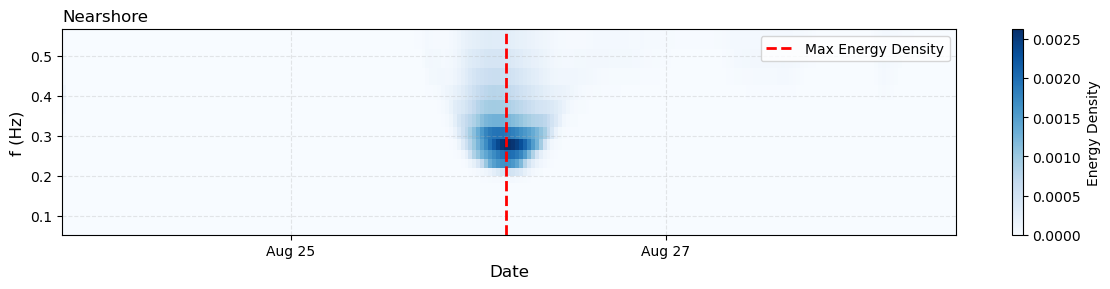

In [31]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(wave_energy_file)

# Target coordinates (update to your specific location)
target_coord = (730277, 3175096)

# Extract element center coordinates
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest element index
distances = np.linalg.norm(elem_coords - np.array(target_coord), axis=1)
nearest_idx = np.argmin(distances)

print(f"Nearest element index: {nearest_idx}")

# Read wave energy density data for the nearest element
data = ds.read(items=["Energy density"], elements=[nearest_idx])

# Extract data for the nearest element
wave_energy_spectrum = data[0].values[:, :, :]  # Shape: (Time, Directions, Frequencies)

# Time, directions, and frequencies
time = np.array(ds.time)  # Shape: (229,)
frequencies = np.array(ds.frequencies)  # Shape: (25,)

# Compute mean wave energy over all directions
mean_energy_spectrum = np.mean(wave_energy_spectrum, axis=1)  # Shape: (229, 25)

# Find time step where energy density is maximum
max_energy_idx = np.argmax(mean_energy_spectrum.sum(axis=1))
max_energy_time = time[max_energy_idx]

# **Ensure correct dimensions for pcolormesh**
T, F = np.meshgrid(time, frequencies, indexing="xy")  # Shape: (25, 229)

print(f"T shape: {T.shape}, F shape: {F.shape}, Energy spectrum shape: {mean_energy_spectrum.T.shape}")

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Create pcolormesh with corrected dimensions
c = ax.pcolormesh(T, F, mean_energy_spectrum.T, cmap="Blues", shading='auto')

# Set date formatting for x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Show more dates

# Labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("f (Hz)", fontsize=12)
ax.set_title("Nearshore", loc="left", fontsize=12)

# Add vertical line where energy density is max
ax.axvline(x=max_energy_time, color="red", linestyle="--", linewidth=2, label="Max Energy Density")

# Colorbar (Fixing tick values)
cb = plt.colorbar(c, ax=ax, orientation="vertical", label="Energy Density")
cb.ax.tick_params(labelsize=10)

# Grid lines
ax.grid(True, linestyle="--", alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.legend()
plt.show()


Nearest element index: 16665
T shape: (25, 229), F shape: (25, 229), Energy spectrum shape: (25, 229)


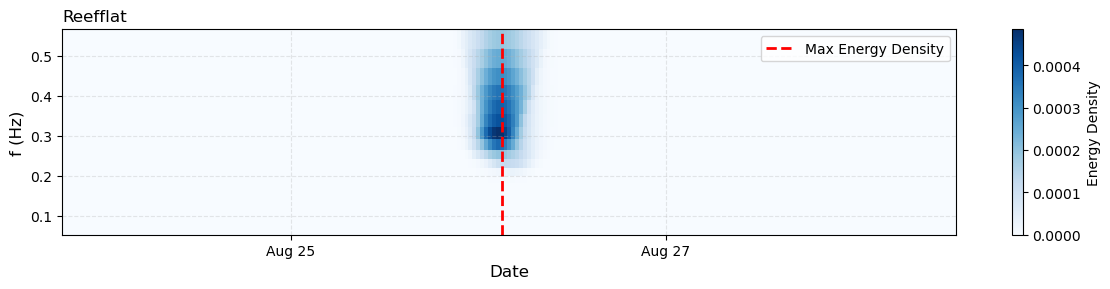

In [32]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(wave_energy_file)

# Target coordinates (update to your specific location)
target_coord = (731037, 3175492)

# Extract element center coordinates
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest element index
distances = np.linalg.norm(elem_coords - np.array(target_coord), axis=1)
nearest_idx = np.argmin(distances)

print(f"Nearest element index: {nearest_idx}")

# Read wave energy density data for the nearest element
data = ds.read(items=["Energy density"], elements=[nearest_idx])

# Extract data for the nearest element
wave_energy_spectrum = data[0].values[:, :, :]  # Shape: (Time, Directions, Frequencies)

# Time, directions, and frequencies
time = np.array(ds.time)  # Shape: (229,)
frequencies = np.array(ds.frequencies)  # Shape: (25,)

# Compute mean wave energy over all directions
mean_energy_spectrum = np.mean(wave_energy_spectrum, axis=1)  # Shape: (229, 25)

# Find time step where energy density is maximum
max_energy_idx = np.argmax(mean_energy_spectrum.sum(axis=1))
max_energy_time = time[max_energy_idx]

# **Ensure correct dimensions for pcolormesh**
T, F = np.meshgrid(time, frequencies, indexing="xy")  # Shape: (25, 229)

print(f"T shape: {T.shape}, F shape: {F.shape}, Energy spectrum shape: {mean_energy_spectrum.T.shape}")

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Create pcolormesh with corrected dimensions
c = ax.pcolormesh(T, F, mean_energy_spectrum.T, cmap="Blues", shading='auto')

# Set date formatting for x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Show more dates

# Labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("f (Hz)", fontsize=12)
ax.set_title("Reefflat", loc="left", fontsize=12)

# Add vertical line where energy density is max
ax.axvline(x=max_energy_time, color="red", linestyle="--", linewidth=2, label="Max Energy Density")

# Colorbar (Fixing tick values)
cb = plt.colorbar(c, ax=ax, orientation="vertical", label="Energy Density")
cb.ax.tick_params(labelsize=10)

# Grid lines
ax.grid(True, linestyle="--", alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.legend()
plt.show()


Nearest element index: 3251
T shape: (25, 229), F shape: (25, 229), Energy spectrum shape: (25, 229)


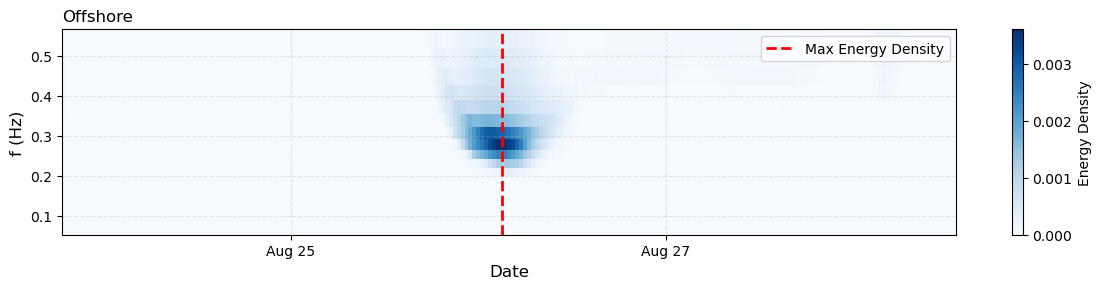

In [34]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"

# Load DFSU file
ds = mikeio.Dfsu(wave_energy_file)

# Target coordinates (update to your specific location)
target_coord = (731545, 3175823)

# Extract element center coordinates
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Find nearest element index
distances = np.linalg.norm(elem_coords - np.array(target_coord), axis=1)
nearest_idx = np.argmin(distances)

print(f"Nearest element index: {nearest_idx}")

# Read wave energy density data for the nearest element
data = ds.read(items=["Energy density"], elements=[nearest_idx])

# Extract data for the nearest element
wave_energy_spectrum = data[0].values[:, :, :]  # Shape: (Time, Directions, Frequencies)

# Time, directions, and frequencies
time = np.array(ds.time)  # Shape: (229,)
frequencies = np.array(ds.frequencies)  # Shape: (25,)

# Compute mean wave energy over all directions
mean_energy_spectrum = np.mean(wave_energy_spectrum, axis=1)  # Shape: (229, 25)

# Find time step where energy density is maximum
max_energy_idx = np.argmax(mean_energy_spectrum.sum(axis=1))
max_energy_time = time[max_energy_idx]

# **Ensure correct dimensions for pcolormesh**
T, F = np.meshgrid(time, frequencies, indexing="xy")  # Shape: (25, 229)

print(f"T shape: {T.shape}, F shape: {F.shape}, Energy spectrum shape: {mean_energy_spectrum.T.shape}")

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Create pcolormesh with corrected dimensions
c = ax.pcolormesh(T, F, mean_energy_spectrum.T, cmap="Blues", shading='auto')

# Set date formatting for x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Show more dates

# Labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("f (Hz)", fontsize=12)
ax.set_title("Offshore", loc="left", fontsize=12)

# Add vertical line where energy density is max
ax.axvline(x=max_energy_time, color="red", linestyle="--", linewidth=2, label="Max Energy Density")

# Colorbar (Fixing tick values)
cb = plt.colorbar(c, ax=ax, orientation="vertical", label="Energy Density")
cb.ax.tick_params(labelsize=10)

# Grid lines
ax.grid(True, linestyle="--", alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.legend()
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mikeio

In [3]:
fn = "D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"
da = mikeio.read(fn)[0]
da

MemoryError: Unable to allocate 16.9 GiB for an array with shape (229, 49661, 16, 25) and data type float32

In [ ]:
da.plot()